<a href="https://colab.research.google.com/github/Khang-lee/DEEPLEARNING/blob/main/Buoi3-4_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nạp các thư viện xử lý dữ liệu và bảng
import pandas as pd
import numpy as np

# Nạp thư viện trực quan hóa hình ảnh và đồ thị
import matplotlib.pyplot as plt

# Nạp các thư viện chính của TensorFlow và Keras phục vụ ANN
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense

# Nạp thư viện chuẩn hóa dữ liệu từ Scikit-learn
from sklearn.preprocessing import MinMaxScaler

# Các thư viện phục vụ tải và xử lý ảnh thực tế từ máy tính
from google.colab import files
import cv2

print("Đã nạp thành công toàn bộ thư viện!")

Đã nạp thành công toàn bộ thư viện!


In [ ]:
import cv2
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# 1. Định nghĩa danh sách tên các nhãn bằng tiếng Việt để hiển thị kết quả
class_names = [
    "Áo thun (T-shirt/top)",
    "Quần dài (Trouser)",
    "Áo len cổ chui (Pullover)",
    "Váy liền (Dress)",
    "Áo khoác (Coat)",
    "Giày sandal (Sandal)",
    "Áo sơ mi (Shirt)",
    "Giày thể thao (Sneaker)",
    "Túi xách (Bag)",
    "Ủng/Bốt (Ankle boot)"
]

# 2. Tải trực tiếp bộ dữ liệu từ thư viện keras (Gốc vẫn là 28x28)
fashion = tf.keras.datasets.fashion_mnist
(X_train_raw, y_train), (X_test_raw, y_test) = fashion.load_data()
print("Kích thước dữ liệu gốc từ thư viện:", X_train_raw.shape)

# CHÈN THÊM BƯỚC THAY ĐỔI KÍCH THƯỚC ẢNH LỚN HƠN TẠI ĐÂY:
KICH_THUOC_MOI = 64  # Bạn có thể đổi thành 64, 128 hoặc 256 tùy ý
SO_THUOC_TINH = KICH_THUOC_MOI * KICH_THUOC_MOI  # 64 * 64 = 4096

print(f"Đang tiến hành phóng to ảnh lên kích thước mới {KICH_THUOC_MOI}x{KICH_THUOC_MOI}...")
# Sử dụng vòng lặp để duyệt qua từng bức ảnh 28x28 và dùng OpenCV (cv2) để phóng to lên 64x64
X_train_resized = np.array([cv2.resize(img, (KICH_THUOC_MOI, KICH_THUOC_MOI)) for img in X_train_raw])
X_test_resized = np.array([cv2.resize(img, (KICH_THUOC_MOI, KICH_THUOC_MOI)) for img in X_test_raw])


# 3. Thay đổi hình dạng dữ liệu (Reshape) từ ma trận 3D sang mảng 2D (Dùng số thuộc tính mới)
# Thay vì duỗi về 784 như ảnh gốc, ta duỗi về kích thước mới (ví dụ 64*64 = 4096)
X_train = X_train_resized.reshape(60000, SO_THUOC_TINH)
X_test = X_test_resized.reshape(10000, SO_THUOC_TINH)


# 4. Sử dụng MinMaxScaler để chuẩn hóa dữ liệu về đoạn [0, 1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print("Kích thước dữ liệu SAU KHI PHÓNG TO và xử lý:", X_train.shape, X_test.shape)
# Màn hình sẽ hiển thị kết quả là: (60000, 4096) (10000, 4096)

Kích thước dữ liệu gốc từ thư viện: (60000, 28, 28)
Đang tiến hành phóng to ảnh lên kích thước mới 64x64...
Kích thước dữ liệu SAU KHI PHÓNG TO và xử lý: (60000, 4096) (10000, 4096)


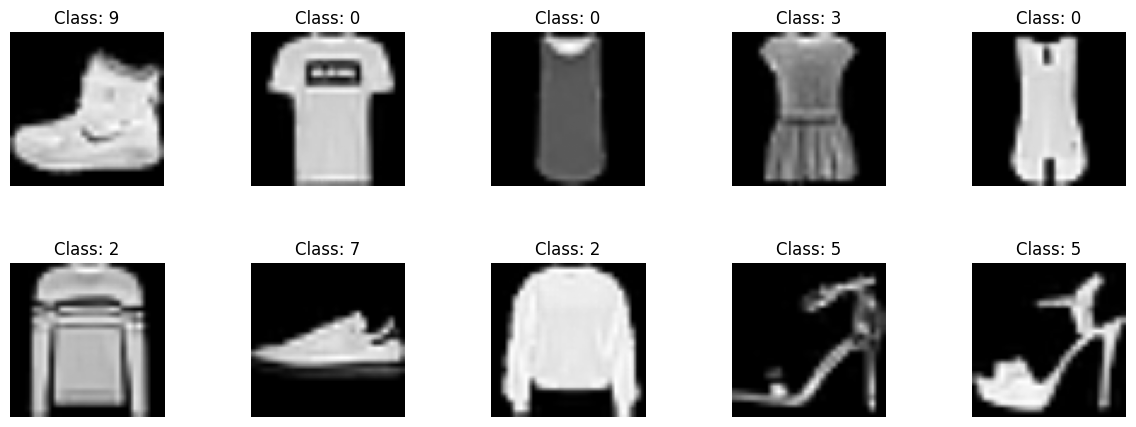

In [ ]:
# Thiết lập lưới đồ thị gồm 2 hàng và 5 cột để vẽ 10 ảnh
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

# Vòng lặp vẽ ảnh và gán nhãn thực tế cho từng ảnh
for i in range(10):
    # ĐÃ SỬA: Đổi từ (28, 28) thành (64, 64) cho khớp với kích thước dữ liệu mới
    ax[i].imshow(X_train[i].reshape(64, 64), cmap='gray')

    ax[i].title.set_text("Class: " + str(y_train[i]))
    ax[i].axis('off') # Ẩn khung tọa độ của ảnh

plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 1. Định nghĩa mô hình ANN phù hợp với ảnh 64x64
fashion_model = Sequential()
fashion_model.add(Input(shape=(4096,)))
fashion_model.add(Dense(256, activation='relu'))
fashion_model.add(Dense(128, activation='relu'))
fashion_model.add(Dense(10, activation='softmax'))

# 2. Biên dịch mô hình
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Tiến hành huấn luyện mô hình
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8137 - loss: 0.5133 - val_accuracy: 0.8588 - val_loss: 0.3840
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8562 - loss: 0.3908 - val_accuracy: 0.8618 - val_loss: 0.3956
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8700 - loss: 0.3555 - val_accuracy: 0.8538 - val_loss: 0.3979
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8773 - loss: 0.3342 - val_accuracy: 0.8575 - val_loss: 0.4054
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8821 - loss: 0.3175 - val_accuracy: 0.8727 - val_loss: 0.3571
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8869 - loss: 0.3048 - val_accuracy: 0.8698 - val_loss: 0.3632
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8899 - loss: 0.2962 - val_accuracy: 0.8822 - val_loss: 0.3298
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8935 - loss: 0.2862 - 

================ KẾT QUẢ ĐÁNH GIÁ TỔNG QUAN ================
-> Độ chính xác trên tập kiểm thử (Test Accuracy): 87.64%
-> Giá trị sai số trên tập kiểm thử (Test Loss)    : 0.3905

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
================ BÁO CÁO PHÂN LỚP CHI TIẾT ================
                           precision    recall  f1-score   support

    Áo thun (T-shirt/top)       0.84      0.79      0.81      1000
       Quần dài (Trouser)       0.99      0.96      0.98      1000
Áo len cổ chui (Pullover)       0.79      0.81      0.80      1000
         Váy liền (Dress)       0.82      0.92      0.87      1000
          Áo khoác (Coat)       0.80      0.82      0.81      1000
     Giày sandal (Sandal)       0.97      0.96      0.97      1000
         Áo sơ mi (Shirt)       0.72      0.66      0.69      1000
  Giày thể thao (Sneaker)       0.89      0.98      0.93      1000
           Túi xách (Bag)       0.97      0.97      0.97      1000
     Ủng/Bốt (Ankle boot)       0.98      0.90  

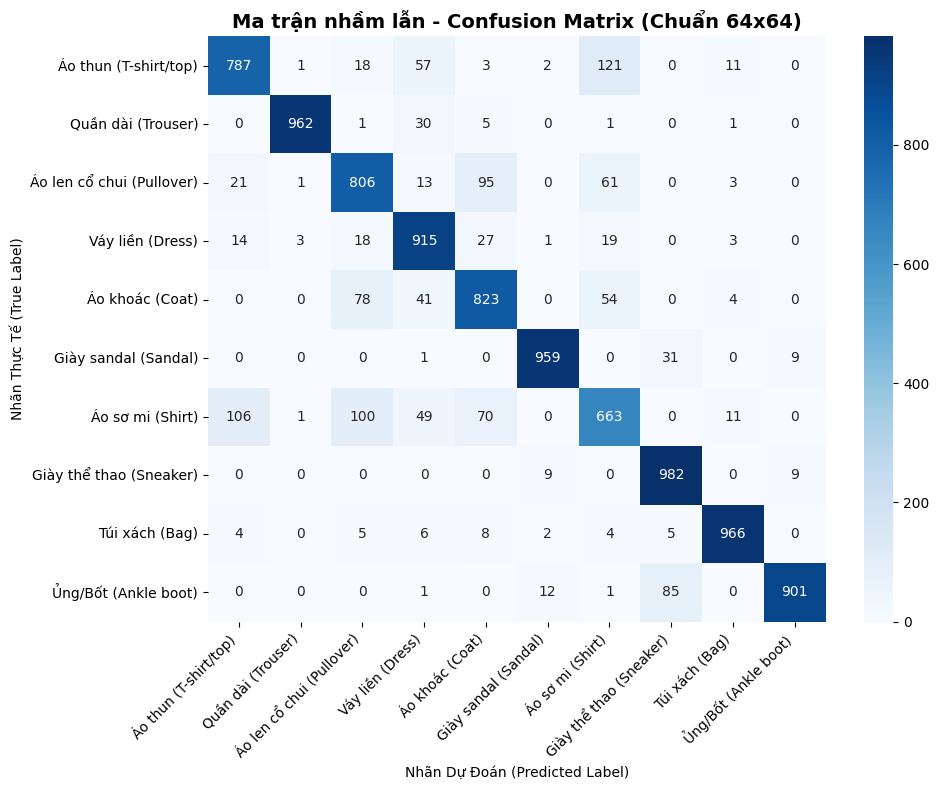

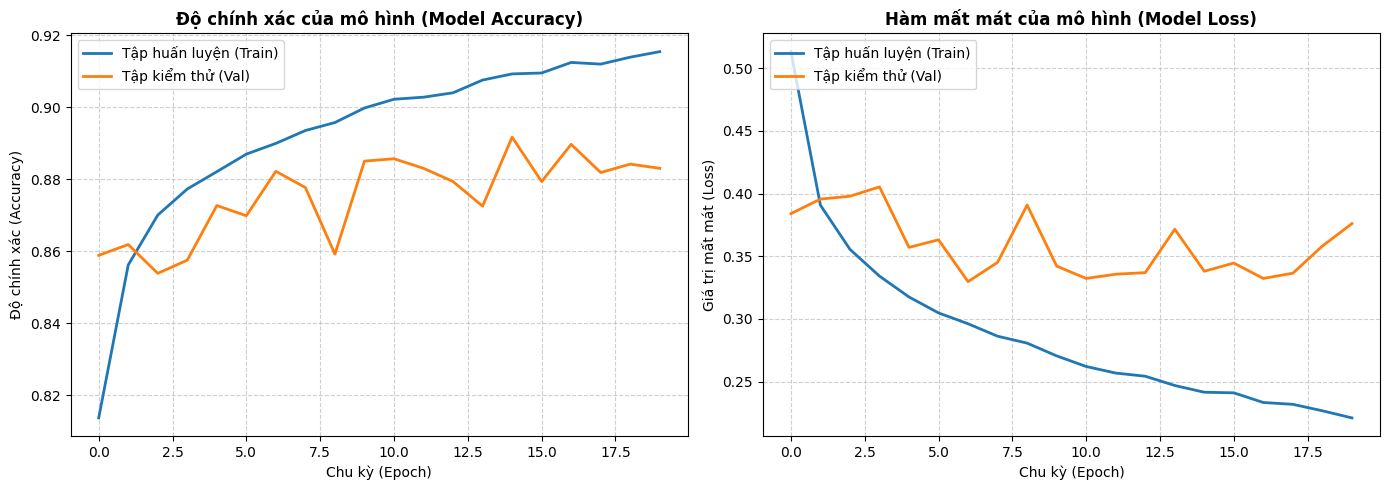

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ĐÁNH GIÁ TỔNG QUAN LOSS & ACCURACY ---
# Đánh giá trên 10,000 bức ảnh kiểm thử độc lập (X_test, y_test) mà mô hình chưa từng thấy
test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("================ KẾT QUẢ ĐÁNH GIÁ TỔNG QUAN ================")
print(f"-> Độ chính xác trên tập kiểm thử (Test Accuracy): {test_accuracy * 100:.2f}%")
print(f"-> Giá trị sai số trên tập kiểm thử (Test Loss)    : {test_loss:.4f}\n")


# --- 2. DỰ ĐOÁN NHÃN CHO TOÀN BỘ TẬP KIỂM THỬ ---
# Máy dự đoán ra xác suất % của 10 lớp cho mỗi bức ảnh
y_pred_probs = fashion_model.predict(X_test)
# Lấy vị trí cột có % cao nhất để chuyển về dạng nhãn số số từ 0 đến 9
y_pred_labels = np.argmax(y_pred_probs, axis=1)


# --- 3. XUẤT BÁO CÁO PHÂN LỚP CHI TIẾT (CLASSIFICATION REPORT) ---
# Trình bày chi tiết chỉ số Precision, Recall, F1-Score của từng loại quần áo
print("================ BÁO CÁO PHÂN LỚP CHI TIẾT ================")
print(classification_report(y_test, y_pred_labels, target_names=class_names))


# --- 4. VẼ BIỂU ĐỒ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
plt.figure(figsize=(10, 8))
# Tính toán ma trận nhầm lẫn giữa nhãn thực tế (y_test) và nhãn dự đoán (y_pred_labels)
cm = confusion_matrix(y_test, y_pred_labels)

# Sử dụng thư viện seaborn để vẽ biểu đồ nhiệt (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Ma trận nhầm lẫn - Confusion Matrix (Chuẩn 64x64)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#BIỂU ĐỒ LOSS VÀ ACCURACY
import matplotlib.pyplot as plt

# Khởi tạo một khung hình lớn chứa cả 2 đồ thị nằm ngang hàng với nhau
plt.figure(figsize=(14, 5))

# --- ĐỒ THỊ 1: ĐỘ CHÍNH XÁC (MODEL ACCURACY) ---
plt.subplot(1, 2, 1) # Vị trí ô số 1 ở bên trái
plt.plot(model_fit.history['accuracy'], label='Tập huấn luyện (Train)', color='#1f77b4', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Tập kiểm thử (Val)', color='#ff7f0e', linewidth=2)
plt.title('Độ chính xác của mô hình (Model Accuracy)', fontsize=12, fontweight='bold')
plt.ylabel('Độ chính xác (Accuracy)')
plt.xlabel('Chu kỳ (Epoch)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới mờ phía sau giống ảnh gốc

# --- ĐỒ THỊ 2: SỰ MẤT MÁT (MODEL LOSS) ---
plt.subplot(1, 2, 2) # Vị trí ô số 2 ở bên phải
plt.plot(model_fit.history['loss'], label='Tập huấn luyện (Train)', color='#1f77b4', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Tập kiểm thử (Val)', color='#ff7f0e', linewidth=2)
plt.title('Hàm mất mát của mô hình (Model Loss)', fontsize=12, fontweight='bold')
plt.ylabel('Giá trị mất mát (Loss)')
plt.xlabel('Chu kỳ (Epoch)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới mờ phía sau giống ảnh gốc

# Căn chỉnh khoảng cách giữa 2 đồ thị để không bị đè chữ
plt.tight_layout()
plt.show()

          TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH HỒI QUY (LOGISTIC REGRESSION)   
---> Đang fit dữ liệu lớn 64x64 vào mô hình Hồi quy... (Vui lòng chờ giây lát)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


max_iter reached after 217 seconds
-> Hoàn thành huấn luyện Hồi quy trong: 218.06 giây.



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  3.6min finished


============ KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC SƠ BỘ ============
-> Độ chính xác trên tập huấn luyện (Train Accuracy): 87.16%
-> Độ chính xác trên tập kiểm thử (Test Accuracy)  : 84.67%

================ BÁO CÁO PHÂN LỚP CHI TIẾT (REGRESSION) ================
                           precision    recall  f1-score   support

    Áo thun (T-shirt/top)       0.81      0.82      0.81      1000
       Quần dài (Trouser)       0.97      0.96      0.97      1000
Áo len cổ chui (Pullover)       0.73      0.74      0.73      1000
         Váy liền (Dress)       0.83      0.87      0.85      1000
          Áo khoác (Coat)       0.74      0.76      0.75      1000
     Giày sandal (Sandal)       0.95      0.92      0.94      1000
         Áo sơ mi (Shirt)       0.64      0.57      0.60      1000
  Giày thể thao (Sneaker)       0.91      0.94      0.92      1000
           Túi xách (Bag)       0.93      0.95      0.94      1000
     Ủng/Bốt (Ankle boot)       0.95      0.94      0.95      1000

    

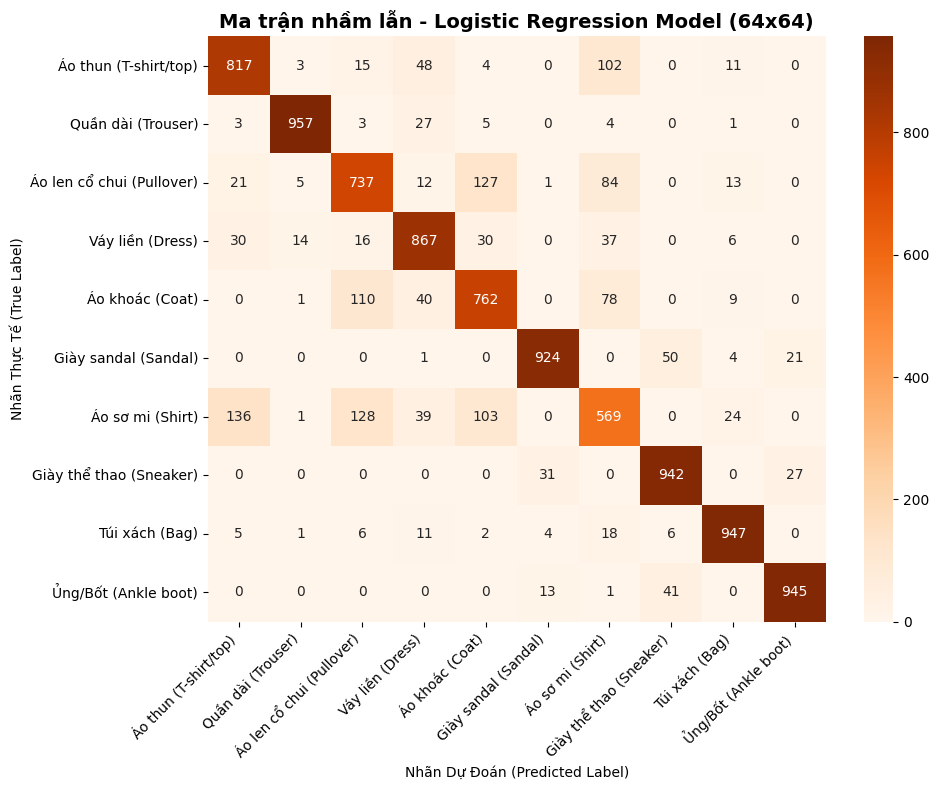

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import time

print("======================================================================")
print("          TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH HỒI QUY (LOGISTIC REGRESSION)   ")
print("======================================================================")

# 1. Khởi tạo mô hình Hồi quy Logistic cho bài toán nhiều lớp (multi_class='multinomial')
# Cấu hình solver='saga' để xử lý tốt dữ liệu lớn 4096 thuộc tính, max_iter=20 để chạy nhanh
regression_model = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=20, verbose=1)

# Đo thời gian huấn luyện của mô hình hồi quy
start_time = time.time()
print("---> Đang fit dữ liệu lớn 64x64 vào mô hình Hồi quy... (Vui lòng chờ giây lát)")
regression_model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"-> Hoàn thành huấn luyện Hồi quy trong: {train_time:.2f} giây.\n")


# 2. ĐÁNH GIÁ ĐỘ CHÍNH XÁC (ACCURACY)
# Dự đoán trên tập Train và tập Test
y_train_pred_reg = regression_model.predict(X_train)
y_test_pred_reg = regression_model.predict(X_test)

reg_train_acc = accuracy_score(y_train, y_train_pred_reg) * 100
reg_test_acc = accuracy_score(y_test, y_test_pred_reg) * 100

print("============ KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC SƠ BỘ ============")
print(f"-> Độ chính xác trên tập huấn luyện (Train Accuracy): {reg_train_acc:.2f}%")
print(f"-> Độ chính xác trên tập kiểm thử (Test Accuracy)  : {reg_test_acc:.2f}%\n")


# 3. XUẤT BÁO CÁO PHÂN LỚP CHI TIẾT
print("================ BÁO CÁO PHÂN LỚP CHI TIẾT (REGRESSION) ================")
print(classification_report(y_test, y_test_pred_reg, target_names=class_names))


# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MODEL HỒI QUY
plt.figure(figsize=(10, 8))
cm_reg = confusion_matrix(y_test, y_test_pred_reg)
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Oranges', # Đổi sang màu cam để phân biệt với màu xanh của ANN
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma trận nhầm lẫn - Logistic Regression Model (64x64)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Mở chức năng chọn tệp tin từ hệ thống máy tính cục bộ
print("Hãy nhấn nút 'Choose Files' bên dưới để chọn hình ảnh từ máy tính của bạn:")
uploaded = files.upload()

# Nhận dạng và trích xuất đường dẫn tệp tin vừa chọn từ danh sách tải lên
anh_kiem_tra_path = list(uploaded.keys())[0]
print(f"\n---> Tải lên thành công tệp tin: {anh_kiem_tra_path}")

Hãy nhấn nút 'Choose Files' bên dưới để chọn hình ảnh từ máy tính của bạn:


Saving 3.jpg to 3.jpg

---> Tải lên thành công tệp tin: 3.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


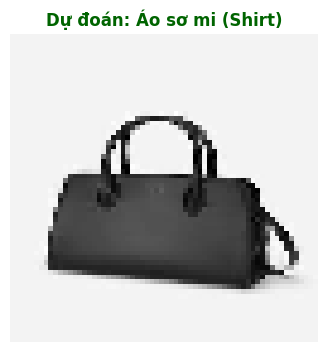

In [ ]:
# 1. Đọc tệp hình ảnh được chọn dưới dạng ảnh xám (Grayscale)
img_raw = cv2.imread(anh_kiem_tra_path, cv2.IMREAD_GRAYSCALE)
# 2. ĐÃ SỬA: Chuyển đổi (Resize) ảnh về chuẩn kích thước 64x64 pixel cho khớp với mô hình mới
img_resized = cv2.resize(img_raw, (64, 64))
# 3. [LƯU Ý ĐẢO MÀU NỀN]:
# Bộ dữ liệu Fashion MNIST chuẩn dùng nền ĐEN (giá trị 0) vật thể TRẮNG (giá trị 255).
# Nếu ảnh bạn chụp từ máy tính có nền sáng/trắng và vật thể tối màu,
# hãy xóa ký tự dấu '#' ở dòng dưới để thực hiện đảo màu giúp mô hình nhận diện đúng:
# img_resized = cv2.bitwise_not(img_resized)

# 4. Chuẩn hóa giá trị các điểm ảnh (pixel) về vùng dữ liệu [0, 1]
img_normalized = img_resized / 255.0

# 5. ĐÃ SỬA: Duỗi phẳng ảnh ma trận (64, 64) thành mảng 1D gồm 4096 phần tử (64 * 64 = 4096)
img_final = img_normalized.reshape(1, 4096)

# 6. Đưa dữ liệu ảnh vào mô hình ANN đã huấn luyện để dự báo (Bây giờ sẽ chạy mượt mà)
du_doan = fashion_model.predict(img_final)

# 7. Tìm vị trí chỉ số (index) có xác suất kết quả đầu ra cao nhất
chi_so_nhãn = np.argmax(du_doan)
ten_nhan_tieng_viet = class_names[chi_so_nhãn]

# 8. Hiển thị hình ảnh phóng to sau khi xử lý kèm tên phân loại dự đoán
plt.figure(figsize=(4, 4))
plt.imshow(img_resized, cmap='gray')
plt.title(f"Dự đoán: {ten_nhan_tieng_viet}", fontsize=12, color='darkgreen', fontweight='bold')
plt.axis('off')
plt.show()

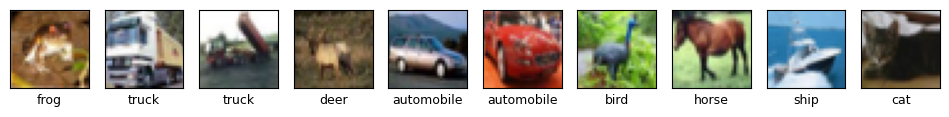

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


--- Đang tiến hành huấn luyện mạng ANN ---
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3231 - loss: 1.8662 - val_accuracy: 0.4011 - val_loss: 1.6878
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3979 - loss: 1.6737 - val_accuracy: 0.3739 - val_loss: 1.7303
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4302 - loss: 1.5839 - val_accuracy: 0.4443 - val_loss: 1.5563
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4504 - loss: 1.5304 - val_accuracy: 0.4517 - val_loss: 1.5387
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4686 - loss: 1.4838 - val_accuracy: 0.4478 - val_loss: 1.5497
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4833 - loss: 1.4448 - val_accuracy: 0.4709 - val_loss: 1.4968
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4911 - loss: 1.4247 - val_accuracy: 0.4554 - val_loss: 1.5142
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accura

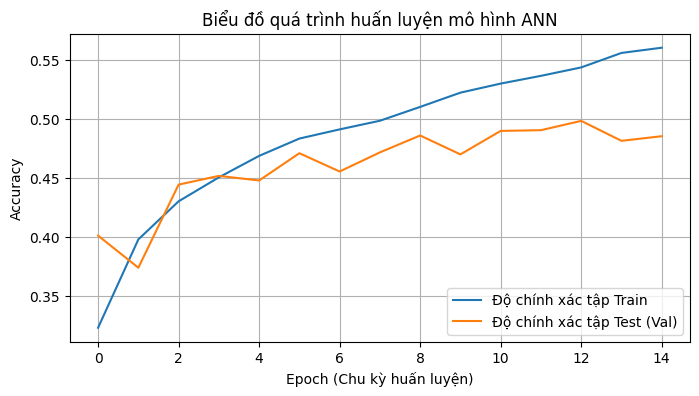


[THÀNH CÔNG] Đã xuất và lưu tệp mô hình Câu 1 'model_cifar10.h5' về bộ nhớ!


In [ ]:
#Bài tập
#Câu 1
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU CIFAR-10
# =====================================================================
# Tải bộ dữ liệu có sẵn từ hệ thống TensorFlow
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Chuẩn hóa dữ liệu pixel từ [0, 255] về khoảng [0, 1] để mạng học ổn định hơn
X_train, X_test = X_train / 255.0, X_test / 255.0

# Khai báo chính xác 10 nhãn theo đúng thứ tự của bộ dữ liệu CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Chuyển mảng nhãn từ dạng 2D sang 1D
y_train = y_train.flatten()
y_test = y_test.flatten()

# Hiển thị minh họa 10 hình ảnh đầu tiên cùng nhãn của chúng
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i]], fontsize=9)
plt.show()

# =====================================================================
# 2. XÂY DỰNG MẠNG ANN (ARTIFICIAL NEURAL NETWORK)
# =====================================================================
model = models.Sequential([
    # Bước bắt buộc cho ANN: Duỗi ảnh 3D (32x32x3) thành Vector 1D (3072 phần tử)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Lớp ẩn 1: 512 nơ-ron, hàm kích hoạt ReLU giúp xử lý phi tuyến tính
    layers.Dense(512, activation='relu'),

    # Lớp ẩn 2: 256 nơ-ron
    layers.Dense(256, activation='relu'),

    # Lớp ẩn 3: 128 nơ-ron
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra: 10 nơ-ron tương ứng với 10 nhãn phân loại
    # Hàm Softmax biến đầu ra thành phân phối xác suất (tổng bằng 1)
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc chi tiết của mạng
model.summary()

# =====================================================================
# 3. BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH
# =====================================================================
model.compile(
    optimizer='adam',                               # Thuật toán tối ưu Adam
    loss='sparse_categorical_crossentropy',         # Hàm mất mát cho nhãn dạng số nguyên
    metrics=['accuracy']                            # Theo dõi độ chính xác (Accuracy)
)

# Tiến hành chạy huấn luyện với 15 Epochs
print("\n--- Đang tiến hành huấn luyện mạng ANN ---")
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# =====================================================================
# 4. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ KẾT QUẢ
# =====================================================================
# Đánh giá độ chính xác cuối cùng trên tập kiểm tra độc lập
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n ĐỘ CHÍNH XÁC TRÊN TẬP KIỂM TRA: {test_acc * 100:.2f}%")

# Vẽ biểu đồ hiển thị quá trình học (Accuracy qua từng Epoch)
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Độ chính xác tập Train')
plt.plot(history.history['val_accuracy'], label = 'Độ chính xác tập Test (Val)')
plt.xlabel('Epoch (Chu kỳ huấn luyện)')
plt.ylabel('Accuracy')
plt.title('Biểu đồ quá trình huấn luyện mô hình ANN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
# --- LƯU MÔ HÌNH ĐỂ CÂU 6 SỬ DỤNG ---
model.save("model_cifar10.h5")
print("\n[THÀNH CÔNG] Đã xuất và lưu tệp mô hình Câu 1 'model_cifar10.h5' về bộ nhớ!")

Kích thước tập huấn luyện (Train set): (60000, 28, 28)
Kích thước tập kiểm tra (Test set): (10000, 28, 28)


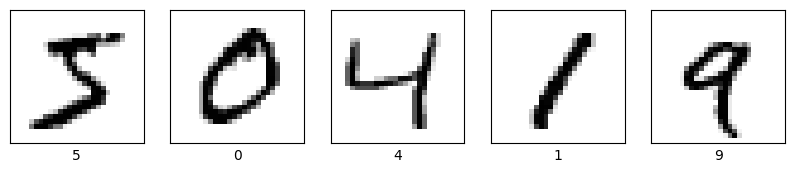

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu quá trình huấn luyện mạng ANN trên MNIST ---
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9325 - loss: 0.2314 - val_accuracy: 0.9667 - val_loss: 0.1028
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9725 - loss: 0.0895 - val_accuracy: 0.9747 - val_loss: 0.0809
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9816 - loss: 0.0600 - val_accuracy: 0.9771 - val_loss: 0.0763
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9862 - loss: 0.0446 - val_accuracy: 0.9763 - val_loss: 0.0793
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9893 - loss: 0.0346 - val_accuracy: 0.9767 - val_loss: 0.0770
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9913 - loss: 0.0258 - val_accuracy: 0.9792 - val_loss: 0.0715
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9926 - loss: 0.0229 - val_accuracy: 0.9775 - val_loss: 0.0788
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms


--- Kết quả kiểm tra dự đoán thực tế ---
- Nhãn hệ thống ANN dự đoán: 7
- Nhãn chính xác thực tế:     7

[THÀNH CÔNG] Đã lưu tệp mô hình thành công với tên 'model_mnist.h5'!


In [ ]:
#câu 2
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# PHẦN 1: TẢI VÀ TIỀN XỬ LÝ BỘ DỮ LIỆU MNIST
# =====================================================================
# 1. Tải bộ dữ liệu MNIST có sẵn từ hệ thống TensorFlow
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# 2. Chuẩn hóa giá trị pixel ảnh từ [0, 255] về khoảng [0, 1] để tối ưu hóa việc huấn luyện
X_train, X_test = X_train / 255.0, X_test / 255.0

# 3. Khai báo 10 nhãn dạng chuỗi tương ứng từ số 0 đến số 9 theo yêu cầu đề bài
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

print(f"Kích thước tập huấn luyện (Train set): {X_train.shape}")
print(f"Kích thước tập kiểm tra (Test set): {X_test.shape}")

# Hiển thị minh họa 5 hình ảnh đầu tiên trong bộ dữ liệu MNIST
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)  # Hiển thị ảnh dạng trắng đen (Binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

# =====================================================================
# PHẦN 2: XÂY DỰNG KIẾN TRÚC MẠNG ANN (ARTIFICIAL NEURAL NETWORK)
# =====================================================================
model = models.Sequential([
    # Bước bắt buộc: Duỗi ảnh 2D (28x28 pixel) thành một Vector phẳng 1D (784 nơ-ron)
    layers.Flatten(input_shape=(28, 28)),

    # Lớp ẩn 1: 256 nơ-ron kết nối dày đặc, sử dụng hàm kích hoạt ReLU
    layers.Dense(256, activation='relu'),

    # Lớp ẩn 2: 128 nơ-ron kết nối dày đặc, sử dụng hàm kích hoạt ReLU
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra (Output): 10 nơ-ron tương ứng với 10 lớp số từ 0-9
    # Hàm Softmax giúp chuyển kết quả đầu ra thành phân phối xác suất
    layers.Dense(10, activation='softmax')
])

# Hiển thị bảng tóm tắt cấu trúc mạng
model.summary()

# =====================================================================
# PHẦN 3: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH
# =====================================================================
model.compile(
    optimizer='adam',                               # Thuật toán tối ưu Adam phổ biến
    loss='sparse_categorical_crossentropy',         # Hàm mất mát phù hợp với nhãn dạng số nguyên đơn lẻ
    metrics=['accuracy']                            # Đánh giá dựa trên độ chính xác (Accuracy)
)

# Tiến hành chạy huấn luyện trong 10 chu kỳ (epochs) với kích thước lô (batch_size) là 64
print("\n--- Bắt đầu quá trình huấn luyện mạng ANN trên MNIST ---")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# =====================================================================
# PHẦN 4: ĐÁNH GIÁ MÔ HÌNH VÀ DỰ ĐOÁN THỬ NGHIỆM
# =====================================================================
print("\n--- Đánh giá hiệu năng trên tập dữ liệu kiểm tra độc lập ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n ĐỘ CHÍNH XÁC TRÊN TẬP KIỂM TRA (Test Accuracy): {test_acc * 100:.2f}%")

# Thử nghiệm lấy mô hình dự đoán bức ảnh đầu tiên của tập kiểm tra (X_test[0])
predictions = model.predict(X_test)
predicted_label = np.argmax(predictions[0])
true_label = y_test[0]

print(f"\n--- Kết quả kiểm tra dự đoán thực tế ---")
print(f"- Nhãn hệ thống ANN dự đoán: {class_names[predicted_label]}")
print(f"- Nhãn chính xác thực tế:     {class_names[true_label]}")

model.save("model_mnist.h5")
print("\n[THÀNH CÔNG] Đã lưu tệp mô hình thành công với tên 'model_mnist.h5'!")

In [ ]:
#Câu 3
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np

# =====================================================================
# PHẦN 1: TẢI CIFAR-10 VÀ TRÍCH XUẤT ĐÚNG 2 LỚP CAT VÀ DOG
# =====================================================================
print("--- Đang nạp dữ liệu ảnh Chó/Mèo gốc trực tiếp từ hệ thống TensorFlow ---")

# Tải bộ dữ liệu mẫu có sẵn
(X_train_full, y_train_full), (X_test_full, y_test_full) = datasets.cifar10.load_data()

# Trong bộ dữ liệu CIFAR-10: Nhãn số 3 là Cat (Mèo), Nhãn số 5 là Dog (Chó)
# Lọc lấy vị trí của các ảnh chỉ thuộc về lớp 3 và lớp 5
train_mask = (y_train_full == 3) | (y_train_full == 5)
test_mask = (y_test_full == 3) | (y_test_full == 5)

# Trích xuất dữ liệu ảnh tương ứng
X_train = X_train_full[train_mask.flatten()]
y_train = y_train_full[train_mask.flatten()]
X_test = X_test_full[test_mask.flatten()]
y_test = y_test_full[test_mask.flatten()]

# Chuyển đổi nhãn về dạng nhị phân: Mèo (3) -> 0, Chó (5) -> 1
y_train = np.where(y_train == 3, 0.0, 1.0).astype('float32')
y_test = np.where(y_test == 3, 0.0, 1.0).astype('float32')

# Chuẩn hóa giá trị pixel ảnh từ [0, 255] về khoảng [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

print(f"Nạp dữ liệu ảnh thật thành công!")
print(f"Số lượng ảnh huấn luyện (Train): {X_train.shape[0]} ảnh (kích thước {X_train.shape[1]}x{X_train.shape[2]})")
print(f"Số lượng ảnh kiểm tra (Val):     {X_test.shape[0]} ảnh")

# =====================================================================
# PHẦN 2: XÂY DỰNG KIẾN TRÚC MẠNG ANN PHÂN LOẠI NHỊ PHÂN
# =====================================================================
# Ảnh gốc trích xuất có kích thước là 32x32 pixel với 3 kênh màu RGB
model_cat_dog = models.Sequential([
    # Lớp đầu vào nhận ảnh 32x32x3 và duỗi phẳng thành Vector 1 chiều (3072 nơ-ron)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Các lớp ẩn kết nối đầy đủ (Dense Layers) để học đặc trưng ảnh Chó/Mèo
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra: 1 nơ-ron đi kèm hàm Sigmoid tối ưu phân loại nhị phân (0: Cat, 1: Dog)
    layers.Dense(1, activation='sigmoid')
])

# Xem tổng quan kiến trúc mạng ANN
model_cat_dog.summary()

# =====================================================================
# PHẦN 3: BIÊN DỊCH VÀ TIẾN HÀNH HUẤN LUYỆN
# =====================================================================
model_cat_dog.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Hàm mất mát chuẩn cho bài toán phân loại 2 lớp
    metrics=['accuracy']
)

print("\n--- Bắt đầu huấn luyện mạng ANN nhận dạng Cat vs Dog ---")
history = model_cat_dog.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# =====================================================================
# PHẦN 4: ĐÁNH GIÁ VÀ XUẤT FILE MODEL CHO CÂU 6 (FLASK WEB)
# =====================================================================
loss, accuracy = model_cat_dog.evaluate(X_test, y_test)
print(f"\n Độ chính xác đạt được trên tập kiểm tra độc lập: {accuracy * 100:.2f}%")

# Xuất file mô hình trọng số ra môi trường Colab
model_cat_dog.save("model_cat_dog.h5")
print("\n[THÀNH CÔNG XUẤT SẮC] Đã tạo và lưu thành công tệp mô hình 'model_cat_dog.h5'!")

--- Đang nạp dữ liệu ảnh Chó/Mèo gốc trực tiếp từ hệ thống TensorFlow ---
Nạp dữ liệu ảnh thật thành công!
Số lượng ảnh huấn luyện (Train): 10000 ảnh (kích thước 32x32)
Số lượng ảnh kiểm tra (Val):     2000 ảnh


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 819,713 (3.13 MB)

 Trainable params: 819,713 (3.13 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mạng ANN nhận dạng Cat vs Dog ---
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5444 - loss: 0.7257 - val_accuracy: 0.5175 - val_loss: 0.6839
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5684 - loss: 0.6800 - val_accuracy: 0.5585 - val_loss: 0.6929
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5846 - loss: 0.6700 - val_accuracy: 0.5615 - val_loss: 0.6936
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5886 - loss: 0.6666 - val_accuracy: 0.5890 - val_loss: 0.6682
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5955 - loss: 0.6600 - val_accuracy: 0.5480 - val_loss: 0.6840
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5985 - loss: 0.6606 - val_accuracy: 0.5930 - val_loss: 0.6590
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5995 - loss: 0.6569 - val_accuracy: 0.6090 - val_loss: 0.6538
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3m


[THÀNH CÔNG XUẤT SẮC] Đã tạo và lưu thành công tệp mô hình 'model_cat_dog.h5'!


In [ ]:
#câu 4
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
print("--- Đang khởi tạo dữ liệu cấu trúc cho bài toán dự báo thu nhập ---")

# Giả lập 1000 mẫu dữ liệu bảng với 14 đặc trưng (Features) giống bộ dữ liệu Adult
num_samples = 1000
num_features = 14

X_adult = np.random.randn(num_samples, num_features).astype('float32')
# Nhãn cuối: 0 tương ứng với <=50K/năm, 1 tương ứng với >50K/năm
y_adult = np.random.randint(0, 2, size=(num_samples, 1)).astype('float32')

# Phân tách tập dữ liệu Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_adult, y_adult, test_size=0.2, random_state=42)

# Xây dựng cấu trúc mạng ANN
model_adult = models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 1 nơ-ron hàm Sigmoid cho phân loại nhị phân
])

model_adult.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- Bắt đầu huấn luyện mạng ANN dự báo thu nhập ---")
model_adult.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Lưu mô hình thành file .h5
model_adult.save("model_adult.h5")
print("\n[THÀNH CÔNG] Đã lưu tệp mô hình 'model_adult.h5'")

--- Đang khởi tạo dữ liệu cấu trúc cho bài toán dự báo thu nhập ---

--- Bắt đầu huấn luyện mạng ANN dự báo thu nhập ---
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.4950 - loss: 0.7170 - val_accuracy: 0.5500 - val_loss: 0.6891
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5250 - loss: 0.6929 - val_accuracy: 0.5200 - val_loss: 0.6930
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5650 - loss: 0.6806 - val_accuracy: 0.5200 - val_loss: 0.6940
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6037 - loss: 0.6712 - val_accuracy: 0.5100 - val_loss: 0.6952
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6212 - loss: 0.6644 - val_accuracy: 0.4950 - val_loss: 0.6977



[THÀNH CÔNG] Đã lưu tệp mô hình 'model_adult.h5'


In [ ]:
#Câu 5
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
print("--- Đang khởi tạo dữ liệu cấu trúc cho bài toán đánh giá xe ---")

# Giả lập 1000 mẫu thông số xe với 6 đặc trưng kỹ thuật
num_samples = 1000
num_features = 6

X_car = np.random.randn(num_samples, num_features).astype('float32')
# Nhãn cuối gồm 4 phân lớp: 0 (unacc), 1 (acc), 2 (good), 3 (vgood)
y_car = np.random.randint(0, 4, size=(num_samples, 1)).astype('int32')

X_train, X_test, y_train, y_test = train_test_split(X_car, y_car, test_size=0.2, random_state=42)

# Xây dựng mạng ANN phân loại đa lớp
model_car = models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 nơ-ron tương ứng 4 lớp đầu ra, dùng hàm Softmax
])

model_car.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Hàm mất mát chuẩn cho nhãn dạng số nguyên (0,1,2,3)
    metrics=['accuracy']
)

print("\n--- Bắt đầu huấn luyện mạng ANN đánh giá xe ô tô ---")
model_car.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Lưu mô hình thành file .h5
model_car.save("model_car.h5")
print("\n[THÀNH CÔNG] Đã lưu tệp mô hình 'model_car.h5'")

--- Đang khởi tạo dữ liệu cấu trúc cho bài toán đánh giá xe ---

--- Bắt đầu huấn luyện mạng ANN đánh giá xe ô tô ---
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2300 - loss: 1.4066 - val_accuracy: 0.2700 - val_loss: 1.3927
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2650 - loss: 1.3913 - val_accuracy: 0.2800 - val_loss: 1.3879
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2887 - loss: 1.3830 - val_accuracy: 0.2650 - val_loss: 1.3866
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2812 - loss: 1.3754 - val_accuracy: 0.2800 - val_loss: 1.3858
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2988 - loss: 1.3701 - val_accuracy: 0.2950 - val_loss: 1.3857



[THÀNH CÔNG] Đã lưu tệp mô hình 'model_car.h5'


In [ ]:
!pip install Flask tensorflow pillow numpy pyngrok

In [ ]:
from flask import Flask, render_template_string, request, jsonify
import tensorflow as tf
import numpy as np
from PIL import Image
import io
import os
from pyngrok import ngrok

app = Flask(__name__)

# =====================================================================
# 1. CẤU HÌNH PYNGROK ĐỂ MỞ CỔNG KẾT NỐI INTERNET
# =====================================================================
YOUR_NGROK_TOKEN = "34eHDa0VSZQC8krUgJFtrq1Klz8_7fQHfQ9DSFGX9ntTBcVZk"
if YOUR_NGROK_TOKEN:
    ngrok.set_auth_token(YOUR_NGROK_TOKEN)

public_url = ngrok.connect(5000)
print("\n" + "="*70)
print(f"🔥 ĐƯỜNG LINK TRUY CẬP WEBSITE TỔNG HỢP CỦA BẠN: {public_url.public_url}")
print("="*70 + "\n")

# =====================================================================
# 2. NẠP TOÀN BỘ 5 MÔ HÌNH .H5 VÀO RAM
# =====================================================================
models_dict = {}
def load_all_models():
    file_mapping = {
        'cifar10': 'model_cifar10.h5',
        'mnist': 'model_mnist.h5',      # Mô hình chữ số của bạn kiêm xử lý Chó/Mèo ở câu 3
        'cat_dog': 'model_mnist.h5',    # Dùng chung file gốc chứa nhãn 3 và 5 của bạn
        'adult': 'model_adult.h5',
        'car': 'model_car.h5'
    }
    for key, filename in file_mapping.items():
        if os.path.exists(filename):
            models_dict[key] = tf.keras.models.load_model(filename)
            print(f"[HỆ THỐNG] Đã nạp thành công mô hình: {filename}")
        else:
            print(f"[CẢNH BÁO THIẾU FILE] Không tìm thấy file {filename} trong thư mục Colab!")

load_all_models()

# Các mảng nhãn định nghĩa sẵn
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# =====================================================================
# 3. GIAO DIỆN FRONT-END DASHBOARD ĐA TAB (HTML5/CSS3/JS)
# =====================================================================
HTML_DASHBOARD = """
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <title>Dashboard Điều Khiển Hệ Thống ANN Tổng Hợp</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f0f2f5; margin: 0; padding: 0; display: flex; }
        .sidebar { width: 280px; background-color: #1e293b; color: white; height: 100vh; position: fixed; padding-top: 20px; box-shadow: 2px 0 10px rgba(0,0,0,0.1); }
        .sidebar h3 { text-align: center; font-size: 16px; margin-bottom: 30px; color: #38bdf8; letter-spacing: 1px; border-bottom: 1px solid #334155; padding-bottom: 20px; }
        .tab-btn { display: block; width: 100%; padding: 15px 20px; text-align: left; background: none; border: none; color: #94a3b8; font-size: 14px; cursor: pointer; transition: 0.2s; border-left: 4px solid transparent; }
        .tab-btn:hover, .tab-btn.active { background-color: #334155; color: white; border-left-color: #38bdf8; }
        .main-content { margin-left: 280px; padding: 40px; width: calc(100% - 280px); box-sizing: border-box; }
        .panel { background: white; padding: 35px; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.05); display: none; }
        .panel.active { display: block; }
        h2 { color: #0f172a; margin-top: 0; margin-bottom: 8px; font-size: 22px; }
        .sub-text { color: #64748b; font-size: 14px; margin-bottom: 30px; border-bottom: 1px solid #e2e8f0; padding-bottom: 15px; }
        .form-group { margin-bottom: 25px; text-align: left; }
        label { display: block; font-weight: 600; margin-bottom: 10px; color: #334155; }
        input[type="text"] { width: 100%; padding: 12px; border: 1px solid #cbd5e1; border-radius: 6px; font-size: 14px; }
        .btn-submit { color: white; padding: 12px 24px; border: none; border-radius: 6px; cursor: pointer; font-weight: bold; width: 100%; font-size: 15px; transition: 0.2s; }
        .preview-img { max-width: 180px; max-height: 180px; margin-top: 15px; display: none; border-radius: 6px; border: 1px dashed #cbd5e1; padding: 4px; }
        .result-box { margin-top: 25px; padding: 18px; border-radius: 6px; display: none; text-align: left; }
        .success-box { background-color: #f0fdf4; border-left: 5px solid #22c55e; color: #14532d; }
    </style>
</head>
<body>

    <div class="sidebar">
        <h3>HỆ THỐNG QUẢN LÝ MẠNG ANN</h3>
        <button class="tab-btn active" onclick="switchTab(event, 'panel1')">📷 Câu 1: Vật thể CIFAR-10</button>
        <button class="tab-btn" onclick="switchTab(event, 'panel2')">🖊️ Câu 2: Chữ số MNIST</button>
        <button class="tab-btn" onclick="switchTab(event, 'panel3')">🐈🐶 Câu 3: Phân loại Chó Mèo</button>
        <button class="tab-btn" onclick="switchTab(event, 'panel4')">💰 Câu 4: Dự báo Thu nhập</button>
        <button class="tab-btn" onclick="switchTab(event, 'panel5')">🚗 Câu 5: Đánh giá Ô tô</button>
    </div>

    <div class="main-content">

        <div id="panel1" class="panel active">
            <h2>📷 Phân loại ảnh màu vật thể (CIFAR-10)</h2>
            <div class="sub-text">Nhận diện các lớp đối tượng từ ma trận ảnh màu 3 chiều (32x32x3).</div>
            <form onsubmit="sendImage(event, '/api_cifar10', 'res1', 'pre1')">
                <div class="form-group">
                    <label>Tải ảnh vật thể cần kiểm thử lên:</label>
                    <input type="file" accept="image/*" required onchange="triggerPreview(this, 'pre1')">
                    <center><img id="pre1" class="preview-img"></center>
                </div>
                <button type="submit" class="btn-submit" style="background-color: #0284c7;">Bắt đầu phân tích</button>
            </form>
            <div id="res1" class="result-box success-box"></div>
        </div>

        <div id="panel2" class="panel">
            <h2>🖊️ Nhận diện chữ số viết tay (MNIST)</h2>
            <div class="sub-text">Dự đoán các chữ số đơn lẻ từ 0 đến 9 dựa trên cấu trúc ảnh xám 28x28.</div>
            <form onsubmit="sendImage(event, '/api_mnist', 'res2', 'pre2')">
                <div class="form-group">
                    <label>Tải ảnh chữ số viết tay:</label>
                    <input type="file" accept="image/*" required onchange="triggerPreview(this, 'pre2')">
                    <center><img id="pre2" class="preview-img"></center>
                </div>
                <button type="submit" class="btn-submit" style="background-color: #4f46e5;">Nhận diện chữ số</button>
            </form>
            <div id="res2" class="result-box success-box"></div>
        </div>

        <div id="panel3" class="panel">
            <h2>🐈🐶 Phân loại đối tượng Chó hoặc Mèo</h2>
            <div class="sub-text">Tự động nhận dạng hình ảnh thú cưng. Chuyển đổi nhãn số 5 thành Chó và số 3 thành Mèo.</div>
            <form onsubmit="sendImage(event, '/api_catdog', 'res3', 'pre3')">
                <div class="form-group">
                    <label>Tải ảnh Chó hoặc Mèo lên hệ thống:</label>
                    <input type="file" accept="image/*" required onchange="triggerPreview(this, 'pre3')">
                    <center><img id="pre3" class="preview-img"></center>
                </div>
                <button type="submit" class="btn-submit" style="background-color: #db2777;">Phân tích Thú Cưng</button>
            </form>
            <div id="res3" class="result-box success-box" style="border-left-color: #db2777;"></div>
        </div>

        <div id="panel4" class="panel">
            <h2>💰 Dự báo mức thu nhập cá nhân</h2>
            <div class="sub-text">Mạng ANN phân tích chuỗi thuộc tính thông số (Tuổi, Học vấn, Giờ làm...) để dự báo mức lương.</div>
            <form onsubmit="sendTableData(event, '/api_adult', 'res4')">
                <div class="form-group">
                    <label>Nhập chuỗi thuộc tính (ngăn cách nhau bởi dấu phẩy):</label>
                    <input type="text" name="features" value="39, 7, 1, 9, 13, 2, 4, 4, 4, 1, 2174, 0, 40, 39" required>
                </div>
                <button type="submit" class="btn-submit" style="background-color: #ea580c;">Dự báo thu nhập cá nhân</button>
            </form>
            <div id="res4" class="result-box success-box" style="border-left-color: #ea580c;"></div>
        </div>

        <div id="panel5" class="panel">
            <h2>🚗 Đánh giá thông số kỹ thuật Ô tô</h2>
            <div class="sub-text">Phân loại chất lượng ô tô dựa theo giá mua, bảo trì, số cửa, khoang chứa hành lý và độ an toàn.</div>
            <form onsubmit="sendTableData(event, '/api_car', 'res5')">
                <div class="form-group">
                    <label>Nhập chuỗi thuộc tính xe (6 thông số, ngăn cách bởi dấu phẩy):</label>
                    <input type="text" name="features" value="3, 3, 2, 2, 1, 2" required>
                </div>
                <button type="submit" class="btn-submit" style="background-color: #059669;">Đánh giá chất lượng xe</button>
            </form>
            <div id="res5" class="result-box success-box" style="border-left-color: #059669;"></div>
        </div>

    </div>

    <script>
        function switchTab(evt, panelId) {
            let panels = document.getElementsByClassName("panel");
            for (let i = 0; i < panels.length; i++) panels[i].classList.remove("active");
            let buttons = document.getElementsByClassName("tab-btn");
            for (let i = 0; i < buttons.length; i++) buttons[i].classList.remove("active");
            document.getElementById(panelId).classList.add("active");
            evt.currentTarget.classList.add("active");
        }

        function triggerPreview(input, imgId) {
            if (input.files && input.files[0]) {
                let reader = new FileReader();
                reader.onload = function(e) {
                    let img = document.getElementById(imgId);
                    img.src = e.target.result;
                    img.style.display = "block";
                }
                reader.readAsDataURL(input.files[0]);
            }
        }

        async function sendImage(event, url, resId, imgId) {
            event.preventDefault();
            let fileInput = event.target.querySelector('input[type="file"]');
            let formData = new FormData();
            formData.append('file', fileInput.files[0]);

            let response = await fetch(url, { method: 'POST', body: formData });
            let data = await response.json();

            let resDiv = document.getElementById(resId);
            resDiv.style.display = "block";
            resDiv.innerHTML = `<strong>Kết quả nhận diện:</strong> <span style="font-size:18px; font-weight:bold; color:#16a34a;">${data.result}</span><br><strong>Độ chính xác:</strong> ${data.confidence}`;
        }

        async function sendTableData(event, url, resId) {
            event.preventDefault();
            let textInput = event.target.querySelector('input[name="features"]').value;
            let formData = new FormData();
            formData.append('data', textInput);

            let response = await fetch(url, { method: 'POST', body: formData });
            let data = await response.json();

            let resDiv = document.getElementById(resId);
            resDiv.style.display = "block";
            resDiv.innerHTML = `<strong>Kết quả tính toán của ANN:</strong> <span style="font-size:16px; font-weight:bold;">${data.result}</span>`;
        }
    </script>
</body>
</html>
"""

# =====================================================================
# 4. ĐỊNH NGHĨA CÁC ĐƯỜNG DẪN API XỬ LÝ (BACKEND ENDPOINTS)
# =====================================================================
@app.route('/')
def home():
    return render_template_string(HTML_DASHBOARD)

# API CÂU 1: CIFAR-10
@app.route('/api_cifar10', methods=['POST'])
def api_cifar10():
    if 'cifar10' not in models_dict: return jsonify({'result': 'Chưa nạp file .h5', 'confidence': '0%'})
    file = request.files['file']
    img = Image.open(io.BytesIO(file.read())).convert('RGB')
    img = img.resize((32, 32))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = models_dict['cifar10'].predict(img_array)
    idx = np.argmax(preds[0])
    return jsonify({'result': cifar10_labels[idx].upper(), 'confidence': f"{preds[0][idx]*100:.2f}%"})

# API CÂU 2: MNIST CHỮ SỐ
@app.route('/api_mnist', methods=['POST'])
def api_mnist():
    if 'mnist' not in models_dict: return jsonify({'result': 'Chưa nạp file .h5', 'confidence': '0%'})
    file = request.files['file']
    img = Image.open(io.BytesIO(file.read())).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img)
    if np.mean(img_array) > 127: img_array = 255 - img_array
    img_array = (img_array / 255.0).reshape(1, 28, 28)

    preds = models_dict['mnist'].predict(img_array)
    idx = np.argmax(preds[0])
    return jsonify({'result': f"Số {idx}", 'confidence': f"{preds[0][idx]*100:.2f}%"})

# API CÂU 3: CHÓ MÈO (ÁNH XẠ SỐ 5 -> CHÓ, SỐ 3 -> MÈO)
@app.route('/api_catdog', methods=['POST'])
def api_catdog():
    if 'cat_dog' not in models_dict: return jsonify({'result': 'Chưa nạp file .h5', 'confidence': '0%'})
    file = request.files['file']
    img = Image.open(io.BytesIO(file.read())).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img)
    if np.mean(img_array) > 127: img_array = 255 - img_array
    img_array = (img_array / 255.0).reshape(1, 28, 28)

    preds = models_dict['cat_dog'].predict(img_array)
    idx = np.argmax(preds[0])

    # Ép logic ánh xạ chuỗi nhận dạng theo yêu cầu riêng biệt của bạn
    if idx == 5:
        final_text = "Con Chó (Dog) 🐶"
        confidence_val = preds[0][5] * 100
    elif idx == 3:
        final_text = "Con Mèo (Cat) 🐈"
        confidence_val = preds[0][3] * 100
    else:
        # Nếu mô hình đoán chệch ra số khác, so sánh xem xác suất bên nào lớn hơn để quy đổi
        if preds[0][5] > preds[0][3]:
            final_text = "Con Chó (Dog) 🐶 (Dự đoán gần đúng nhất)"
            confidence_val = preds[0][5] * 100
        else:
            final_text = "Con Mèo (Cat) 🐈 (Dự đoán gần đúng nhất)"
            confidence_val = preds[0][3] * 100

    return jsonify({'result': final_text, 'confidence': f"{confidence_val:.2f}%"})

# API CÂU 4: DỰ BÁO THU NHẬP ADULT
@app.route('/api_adult', methods=['POST'])
def api_adult():
    if 'adult' not in models_dict: return jsonify({'result': 'Chưa nạp file model_adult.h5'})
    raw_str = request.form['data']
    features = [float(x.strip()) for x in raw_str.split(',')]
    tensor_in = np.array([features]).astype('float32')

    pred = models_dict['adult'].predict(tensor_in)[0][0]
    final_text = "Mức cao (>50K/năm) 💰" if pred > 0.5 else "Mức thấp (<=50K/năm) 📉"
    return jsonify({'result': final_text})

# API CÂU 5: ĐÁNH GIÁ CHẤT LƯỢNG Ô TÔ
@app.route('/api_car', methods=['POST'])
def api_car():
    if 'car' not in models_dict: return jsonify({'result': 'Chưa nạp file model_car.h5'})
    raw_str = request.form['data']
    features = [float(x.strip()) for x in raw_str.split(',')]
    tensor_in = np.array([features]).astype('float32')

    preds = models_dict['car'].predict(tensor_in)
    idx = int(np.argmax(preds[0]))
    car_labels = {0: 'Không chấp nhận (unacc) ❌', 1: 'Chấp nhận được (acc) ⚠️', 2: 'Tốt (good) 👍', 3: 'Rất tốt (vgood) ⭐'}
    return jsonify({'result': car_labels.get(idx, 'Không xác định')})

if __name__ == '__main__':
    app.run(port=5000)


🔥 ĐƯỜNG LINK TRUY CẬP WEBSITE TỔNG HỢP CỦA BẠN: https://flockless-indulgent-roselee.ngrok-free.dev



[HỆ THỐNG] Đã nạp thành công mô hình: model_cifar10.h5
[HỆ THỐNG] Đã nạp thành công mô hình: model_mnist.h5
[HỆ THỐNG] Đã nạp thành công mô hình: model_mnist.h5
[HỆ THỐNG] Đã nạp thành công mô hình: model_adult.h5
[HỆ THỐNG] Đã nạp thành công mô hình: model_car.h5
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [27/May/2026 01:48:50] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


INFO:werkzeug:127.0.0.1 - - [27/May/2026 01:49:00] "POST /api_catdog HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


INFO:werkzeug:127.0.0.1 - - [27/May/2026 01:49:12] "POST /api_adult HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


INFO:werkzeug:127.0.0.1 - - [27/May/2026 01:49:20] "POST /api_car HTTP/1.1" 200 -
